CO2=0, ecosystem_dGPP_M: slope=-74.977, SE=17.567, p=0.0003
CO2=0, ecosystem_dGPP_C: slope=18.278, SE=9.456, p=0.0656
CO2=0, ecosystem_dGPP_A: slope=-1.526, SE=4.089, p=0.7123
CO2=500, ecosystem_dGPP_M: slope=3.399, SE=13.819, p=0.8079
CO2=500, ecosystem_dGPP_C: slope=35.511, SE=8.766, p=0.0005
CO2=500, ecosystem_dGPP_A: slope=-6.327, SE=3.705, p=0.1012
CO2=0, signed weighted contribution:
[123.75543002 -23.6096516   -0.14577842]
CO2=500, signed weighted contribution:
[26.71352254 67.77689432  5.50958315]


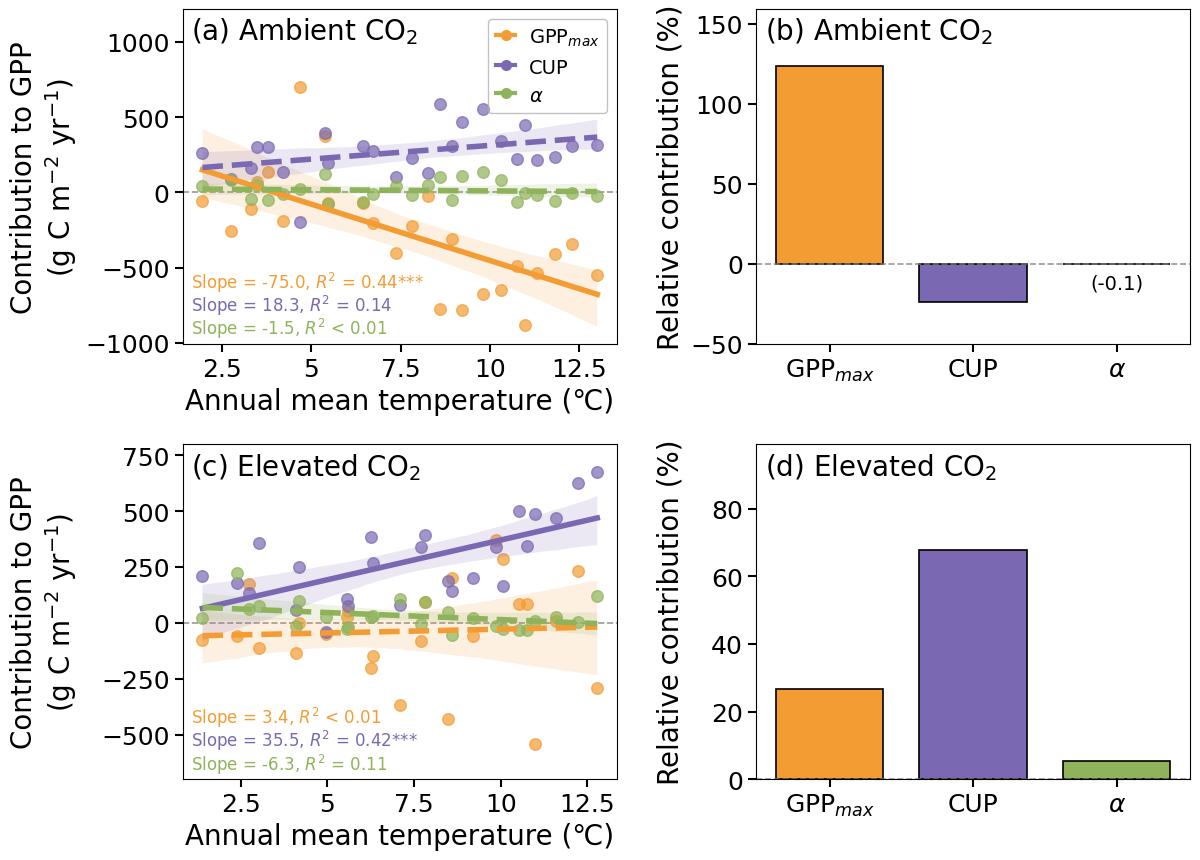

In [1]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# ============================================================
# CONFIG
# ============================================================

FILE_LMDI = "../../data_results/2_results/2-5_1_contribution_25/all_results_LMDI_detail.xlsx"

FILE_SIGN_ECO = (
    "../../data_results/2_results/2-5_1_contribution_25/relative_contribution/"
    "signed_ecosystem_MCA.xlsx"
)

# OUT_DIR = "2_results/2-5_1_contribution_25/figures"
# os.makedirs(OUT_DIR, exist_ok=True)

# OUT_FIG = os.path.join(OUT_DIR, "Fig_ecosystem_LMDI_temp_signed_contribution.png")

CO2_COL = "co2"
X_COL = "temp_mean_anom"
CO2_LEVELS = [0, 500]

VARS_LMDI = [
    ("ecosystem_dGPP_M", "GPP$_{max}$", "#F39C34"),
    ("ecosystem_dGPP_C", "CUP",         "#7B68B3"),
    ("ecosystem_dGPP_A", r"$\alpha$",   "#8FB35A"),
]

VARS_SIGN = [
    ("GPPmax_signed_weighted_%", "GPP$_{max}$", "#F39C34"),
    ("CUP_signed_weighted_%",    "CUP",         "#7B68B3"),
    ("alpha_signed_weighted_%",  r"$\alpha$",   "#8FB35A"),
]

PANEL_LABELS_LEFT = ["(a) Ambient CO$_2$", "(c) Elevated CO$_2$"]
PANEL_LABELS_RIGHT = ["(b) Ambient CO$_2$", "(d) Elevated CO$_2$"]

XLAB_LEFT = "Annual mean temperature (℃)"
YLAB_LEFT = "Contribution to GPP\n(g C m$^{-2}$ yr$^{-1}$)"
YLAB_RIGHT = "Relative contribution (%)"

XSTICK = [2.5, 5, 7.5, 10, 12.5]

YLIM_LEFT = {
    0: (-1009, 1219),
    500: (-699, 799),
}

YLIM_RIGHT = {
    0: (-50, 159),
    500: (0, 99),
}

STAT_POS = {
    0: [(0.02, 0.15), (0.02, 0.08), (0.02, 0.01)],
    500: [(0.02, 0.15), (0.02, 0.08), (0.02, 0.01)],
}


# ============================================================
# STYLE
# ============================================================

def style_ax(ax, labelsize=16):
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=labelsize,
        length=6,
        width=1.5,
        direction="out",
        bottom=True,
        left=True,
    )


# ============================================================
# HELPERS
# ============================================================

def fit_ols(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {
            "slope": np.nan,
            "r2": np.nan,
            "p": np.nan,
            "se": np.nan,
        }

    m = sm.OLS(y, sm.add_constant(x)).fit()

    return {
        "slope": float(m.params[1]),
        "r2": float(m.rsquared),
        "p": float(m.pvalues[1]),
        "se": float(m.bse[1]),
    }


def format_reg_text(stats):
    if not np.isfinite(stats["p"]):
        return "NA"

    stars = (
        "***" if stats["p"] < 0.001
        else "**" if stats["p"] < 0.01
        else "*" if stats["p"] < 0.05
        else ""
    )

    if np.isfinite(stats["r2"]) and stats["r2"] > 0.01:
        return f"Slope = {stats['slope']:.1f}, $R^2$ = {stats['r2']:.2f}{stars}"
    else:
        return f"Slope = {stats['slope']:.1f}, $R^2$ < 0.01{stars}"


def get_signed_values(df_sign, co2v):
    row = df_sign[df_sign[CO2_COL] == co2v]

    if row.shape[0] != 1:
        raise ValueError(f"Expected one row for co2={co2v}, but got {row.shape[0]}")

    values = []
    labels = []
    colors = []

    for col, label, color in VARS_SIGN:
        values.append(float(row.iloc[0][col]))
        labels.append(label)
        colors.append(color)

    return np.array(values), labels, colors


def plot_signed_bar(ax, values, labels, colors, ylim, ylabel=""):
    x = np.arange(len(values))

    ax.bar(
        x,
        values,
        color=colors,
        edgecolor="black",
        linewidth=1.2,
        width=0.75,
    )

    ax.axhline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.8)
    ax.set_ylim(ylim)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=20)

    ax.set_ylabel(ylabel, fontsize=20)
    style_ax(ax, labelsize=18)

    yr = ylim[1] - ylim[0]
    for xi, v in zip(x, values):
        if np.isfinite(v):
            if np.abs(v) < 1:
                va = "bottom" if v >= 0 else "top"
                offset = 0.03 * yr if v >= 0 else -0.03 * yr
                ax.text(
                    xi,
                    v + offset,
                    f"({v:.1f})",
                    ha="center",
                    va=va,
                    fontsize=14,
                )


# ============================================================
# READ DATA
# ============================================================

df_lmdi = pd.read_excel(FILE_LMDI)
df_sign = pd.read_excel(FILE_SIGN_ECO)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10),
    sharex=False,
    sharey=False,
)

# ------------------------------------------------------------
# Left column: LMDI contribution vs temperature
# ------------------------------------------------------------

for i, co2v in enumerate(CO2_LEVELS):
    ax = axes[i, 0]

    d = df_lmdi[df_lmdi[CO2_COL] == co2v].copy()
    x = d[X_COL].to_numpy(float)

    ax.set_xticks(XSTICK)
    ax.set_xticklabels(XSTICK)
    ax.set_ylim(YLIM_LEFT[co2v])

    for idx_var, (var, label, color) in enumerate(VARS_LMDI):
        y = d[var].to_numpy(float)

        stats = fit_ols(x, y)

        print(
            f"CO2={co2v}, {var}: "
            f"slope={stats['slope']:.3f}, "
            f"SE={stats['se']:.3f}, "
            f"p={stats['p']:.4f}"
        )

        linestyle = "-" if np.isfinite(stats["p"]) and stats["p"] < 0.05 else "--"
        reg_text = format_reg_text(stats)

        tx, ty = STAT_POS[co2v][idx_var]
        ax.text(
            tx,
            ty,
            reg_text,
            ha="left",
            va="bottom",
            transform=ax.transAxes,
            fontsize=12,
            color=color,
        )

        sns.regplot(
            x=x,
            y=y,
            ax=ax,
            ci=95,
            color=color,
            scatter_kws=dict(s=70, alpha=0.7),
            line_kws=dict(lw=4, linestyle=linestyle),
        )

    ax.axhline(
        0,
        color="gray",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8,
        zorder=0,
    )

    ax.text(
        0.02,
        0.98,
        PANEL_LABELS_LEFT[i],
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left",
    )

    ax.set_xlabel(XLAB_LEFT, fontsize=20)
    ax.set_ylabel(YLAB_LEFT, fontsize=20)
    style_ax(ax, labelsize=18)


# legend
legend_handles = []
legend_labels = []

for var, label, color in VARS_LMDI:
    h = plt.Line2D(
        [0],
        [0],
        color=color,
        marker="o",
        linestyle="-",
        linewidth=3,
        markersize=7,
        label=label,
    )
    legend_handles.append(h)
    legend_labels.append(label)

leg = axes[0, 0].legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    fontsize=14,
    frameon=True,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.7,
    labelspacing=0.4,
    borderpad=0.4,
)

leg.get_frame().set_facecolor("none")
leg.get_frame().set_edgecolor("0.7")


# ------------------------------------------------------------
# Right column: signed weighted relative contribution
# ------------------------------------------------------------

for i, co2v in enumerate(CO2_LEVELS):
    ax = axes[i, 1]

    values, labels, colors = get_signed_values(df_sign, co2v)

    print(f"CO2={co2v}, signed weighted contribution:")
    print(values)

    plot_signed_bar(
        ax,
        values=values,
        labels=labels,
        colors=colors,
        ylim=YLIM_RIGHT[co2v],
        ylabel=YLAB_RIGHT,
    )

    ax.text(
        0.02,
        0.98,
        PANEL_LABELS_RIGHT[i],
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left",
    )

    ax.set_xlabel("", fontsize=20)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.align_ylabels()
plt.subplots_adjust(wspace=0.32, hspace=0.30)

# plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

# print("Saved figure:")
# print(OUT_FIG)